# Spherical Thin Plate Spline

In [1]:
import numpy as np

from glomar_gridding.io import load_array

# Spliney Stuff
from glomar_gridding.spline import SphericalThinPlateSpline

# For observations
import polars as pl

# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

%matplotlib inline

## Prepare Data

One array from HadSST4 to interpolate.

In [2]:
MONTH, YEAR, MEMBER = 3, 2014, 71

In [3]:
obs = pl.from_pandas(
    load_array(
        f"HadSST.4.0.1.0_ensemble_member_{MEMBER}_{YEAR}_{MONTH:02d}.nc", "tos"
    )
    .to_dataframe()
    .reset_index()
)
obs = obs.filter(
    pl.col("time").dt.month().eq(MONTH) & pl.col("time").dt.year().eq(YEAR)
).drop_nulls()
obs = obs.filter(pl.col("tos").lt(1e4))

### Training Data and Output Grid

The positions must be passed as radians, in the order "latitude", "longitide".

In [4]:
X_train = np.radians(obs.select(["latitude", "longitude"]).to_numpy())
y_train = obs.get_column("tos").to_numpy()

In [5]:
out_grid = np.radians(np.mgrid[-87.5:90:5, -177.5:180:5])
X_test = out_grid.reshape(2, -1).T

## Interpolation

Initialise `SphericalThinPlateSpline` with the training data.

In [6]:
stps = SphericalThinPlateSpline(X_train, y_train)

### No Smoothing

$\lambda = 0$

Get the weights, and fitted values at the training points.

In [7]:
stps.fit(lam=0, set_results=True)

Predict/Interpolate the full grid.

In [8]:
y_pred_0, _ = stps.predict(X_test, compute_se=False)

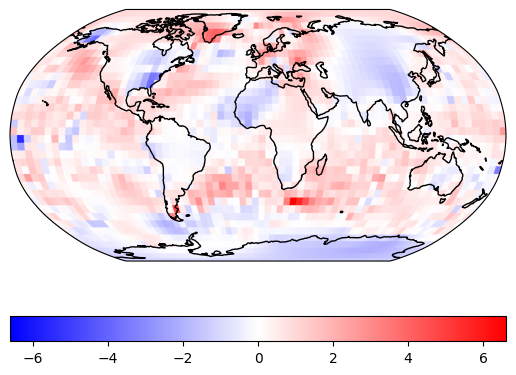

In [9]:
lims1 = np.max(np.abs(y_pred_0))
F1 = plt.Figure()
ax1 = F1.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax1.coastlines()
m1 = ax1.imshow(
    np.flipud(y_pred_0.reshape(out_grid.shape[1:])),
    transform=ccrs.PlateCarree(),
    cmap="bwr",
    vmin=-lims1,
    vmax=lims1,
)
F1.colorbar(m1, orientation="horizontal")
F1

## With Smoothing

Estimate a $\lambda$ value using GCV.

Fit the model, and interpolate with the estimated $\lambda$ value.

In [10]:
stps.fit(set_results=True)
y_pred, _ = stps.predict(X_test)

Estimating Lambda Using GCV


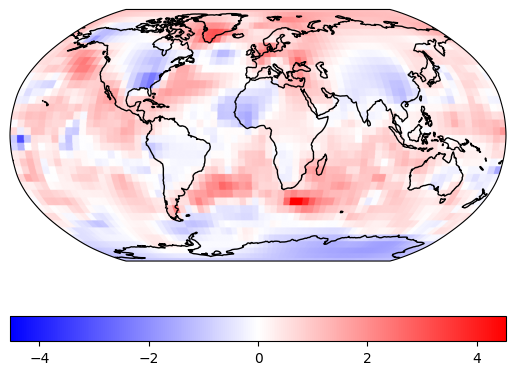

In [11]:
lims2 = np.max(np.abs(y_pred))
F2 = plt.Figure()
ax2 = F2.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax2.coastlines()
m2 = ax2.imshow(
    np.flipud(y_pred.reshape(out_grid.shape[1:])),
    transform=ccrs.PlateCarree(),
    cmap="bwr",
    vmin=-lims2,
    vmax=lims2,
)
F2.colorbar(m2, orientation="horizontal")
F2